## Comment utiliser ce notebook
Cliquer sur une cellule et presser Entrée pour éditer une cellule.<br/>
Appuyer sur Shift+Entrée pour exécuter la cellule.<br/>
Pour répondre à un exercice, remplacer la ligne
```python
# <- completer ici
```
par votre code et exécuter la cellule.
<hr/>

Sous-sections :
[Calculs préliminaires](#preliminaires)&nbsp;|
[Les $k$ plus proches voisins](#knn)&nbsp;

<a id="preliminaires"></a>
### Partie 1 -- Calculs préliminaires

##### Représentation vectorielles des entrées

__Exercice__.$\quad$   
Soit $\overrightarrow{x}$=($u_1$,$u_2$,...,$u_n$)$\in\mathbb{R}^n$
un vecteur de réels.

Quelle structure de données utiliserait-on en Python pour représenter
un tel vecteur ?

Donner des exemples de déclaration pour les deux vecteurs
$\overrightarrow{x_1}=(3,4)$
et
$\overrightarrow{x_2}=(-3,5)$.


Ok


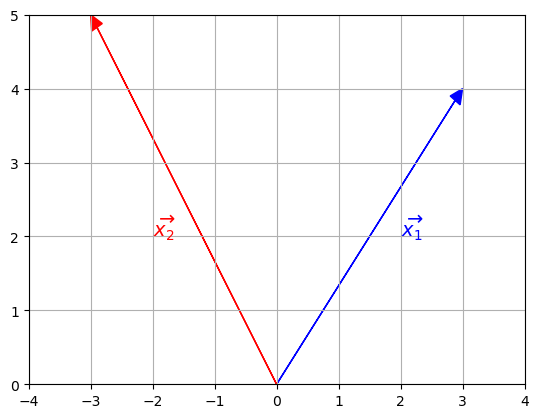

In [3]:
import matplotlib.pyplot as plt
import math

# <- completer ici
# x1 = ...
# x2 = ...
x1 = (3,4)
x2 = (-3,5)

# --------- tests -------- #
try:
    assert x1 is not None, 'Erreur : x1 ne doit pas être nul'
    assert x2 is not None, 'Erreur : b ne doit pas être nul'
    assert len(x1)==2, 'Erreur : le vecteur x1 doit contenir 2 éléments.'
    assert len(x2)==2, 'Erreur : le vecteur x2 doit contenir 2 éléments.'
    print("Ok")
    hl=0.2
    hw=0.2

    def norm(u):
        return math.sqrt(u[0]**2+u[1]**2)

    ax = plt.axes()
    ax.arrow(0, 0, x1[0]*(norm(x1)-hl)/norm(x1), x1[1]*(norm(x1)-hl)/norm(x1), head_width=hw, head_length=hl, fc='blue', ec='blue')
    ax.annotate(r'$\overrightarrow{x_1}$', (2,2),fontsize=14,color='blue')
    ax.arrow(0, 0, x2[0]*(norm(x2)-hl)/norm(x2), x2[1]*(norm(x2)-hl)/norm(x2), head_width=hw, head_length=hl, fc='red', ec='red')
    ax.annotate(r'$\overrightarrow{x_2}$', (-2,2),fontsize=14,color='red')
    plt.grid()

    plt.xlim(-4,4)
    plt.ylim(0,5)
    plt.show()
    
except AssertionError as e:
    print(e) 

##### La distance Euclidienne

La distance Euclidienne $d(x_i,x_j)$ entre deux entrées $x_i$ et $x_j$ est la norme du vecteur $\overrightarrow{x_ix_j}$.

Elle est définie par :
$$
d(x_i,x_j) = \sqrt{(x_j-x_i)^2 + (y_j-y_i)^2}
$$

__Exercice__.$\quad$
Calculer la distance Euclidienne $d(x_1,x_1)$ entre les deux vecteurs $x_1$ et $x_2$ définis ci-dessus, et mettre le résultat dans une variable `d`.

Remarque : en Python,`math.sqrt(a)` peut être utilisé pour calculer la racine carré de `a`.

In [4]:
# <- completer ici
# d = ...
d = math.sqrt((x2[0]-x1[0])**2 + (x2[1]-x1[1])**2)


__Exercice__.$\quad$
On décide de convertir la distance $d$ en mesure de similarité $\sigma_S$ en lui appliquant la fonction exponentielle, de la manière suivante :
$$
\sigma_S(x_i,x_j) = e^{-d(x_i,x_j)}
$$

Calculer la similarité $\sigma_s(x_1,x_2)$ et placer le résultat dans la variable `sim_s`.

Afficher cette valeur.

Remarque : en Python, `math.exp(a)` peut être utilisé pour calculer $e^a$.

In [5]:
sim_s = math.exp(-d)
print(sim_s)

0.0022818642187506046


##### Le tri à bulle

__Exercice__. A l'aide de l'algorithme abstrait vu en cours, implémenter l'algorithme du tri à bulle pour trier le tableau `tab` ci-dessous.

In [6]:
tab = [.8,.2,.87,.1,.5,.08,.1,1.0,.7,.1]

# <- completer ici

n = len(tab)
echange = True
i = 1
while n-1-i>0 and echange:
    echange = False
    for j in range(0,n-i):
        if tab[j]>tab[j+1]:
            tmp = tab[j+1]
            tab[j+1] = tab[j]
            tab[j] = tmp
            echange = True
    i = i + 1

print(tab)

# --------- tests -------- #
try:
    assert tab[-2] == .87, "Erreur : l'élément .87 doit être en avant dernière position dans le tableau trié."
    assert len(tab) == 10, "Erreur : le tableau trié doit contenir 10 éléments."
    print("Ok")
except AssertionError as e:
    print(e)  


[0.08, 0.1, 0.1, 0.1, 0.2, 0.5, 0.7, 0.8, 0.87, 1.0]
Ok


Donner une nouvelle version de l'algorithme de tri à bulle qui place cette fois-ci :
- dans une liste `sorted_values` les éléments de `tab` classés par ordre croissant
- dans une liste `indices` les indices dans le tableau `tab` initial de ces éléments triés.

Remarque : l'instruction `t= tab.copy()` permet de placer dans une liste `t` une copie de la liste `tab`.

In [7]:
tab = [.8,.2,.87,.1,.5,.08,.1,1.0,.7,.1]
# <- completer ici

t = tab.copy()
n = len(t)
indices = list(range(n))
echange = True
i = 1
while n-1-i>0 and echange:
    echange = False
    for j in range(0,n-i):
        if t[j]>t[j+1]:
            tmp = t[j+1]
            t[j+1] = t[j]
            t[j] = tmp
            tmp = indices[j+1]
            indices[j+1] = indices[j]
            indices[j] = tmp
            echange = True
    i = i + 1
sorted_values = t

print(f"{'tableau initial':<20} {tab}")
print(f"{'tableau trié':<20} {sorted_values}")
print(f"{'indices':<20} {indices}")

# --------- tests -------- #
try:
    assert [tab[i] for i in indices] == sorted_values, 'Erreur : indices doit contenir les indices dans tab des éléments triés.'
    print("Ok")
except AssertionError as e:
    print(e)  


tableau initial      [0.8, 0.2, 0.87, 0.1, 0.5, 0.08, 0.1, 1.0, 0.7, 0.1]
tableau trié         [0.08, 0.1, 0.1, 0.1, 0.2, 0.5, 0.7, 0.8, 0.87, 1.0]
indices              [5, 3, 6, 9, 1, 4, 8, 0, 2, 7]
Ok


<a id='knn'></a>
### Partie 2 -- Les $k$ plus proches voisins

Le but de cette partie est d'implémenter une première version de l'algorithme des plus proches voisins.

Pour tester notre implémentation, nous utiliserons ici :
- la mesure de similarité $\sigma_S$ définie plus haut à partir de la distance Euclidienne ;
- une base de cas $CB$ artificielle contenant $9$ couples $(x_i,y_i)$ dans lesquels :
    - $x_i\in \mathbb{R}^2$ est un point du plan en 2D
    - $y_i\in \{0,1\}$ vaut soit $1$ (point bleu) ou $0$ (point rouge)
- $x = (0,3)$ est une nouvelle entrée dont on veut prédire la classe ($0$ ou $1$)

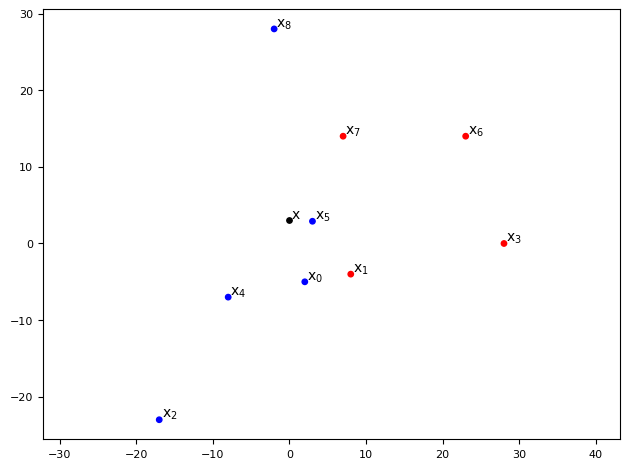

In [1]:
# la base de cas
X = [(2,-5),(8,-4),(-17,-23),(28,0),(-8,-7),(3,2.9),(23,14),(7,14),(-2,28)]
y = [1,0,1,0,1,1,0,0,1]

# la nouvelle entrée
x = (0,3)

# On affiche la base de cas X et la nouvelle entrée x
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
colors = ['blue' if c == 1 else 'red' for c in y]
plt.scatter([u[0] for u in X], [u[1] for u in X],marker='.', s=[60]*len(X), c=colors)
plt.scatter((x[0]), (x[1]), marker='.', s=[60], c=('black'))
for i in range(len(X)):
    ax.annotate(r'x$_{}$'.format(str(i)), (X[i][0]+.3, X[i][1]+.3))
ax.annotate(r'x', (x[0]+.3, x[1]+.3))
plt.axis([-30, 30, -30, 30])
plt.axis('equal')
plt.tight_layout()
plt.show()

##### Etape 1 -- Calculer les similarités

La première étape consiste à calculer les similarités $\sigma_S(x,x_i)$ entre la nouvelle entrée $x$ et chacun des cas $x_i\in CB$.

__Exercice__.$\quad$
Calculer les similarités $\sigma_S(x,x_i) \, \forall i\in [1,n-1]$ et placer les résultats dans une liste appelée `similarites`.


In [9]:
# <- completer ici
similarites = []
for i in range(len(X)):
    xi = X[i]
    sim_i = math.exp(-math.sqrt((x[0]-xi[0])**2 + (x[1]-xi[1])**2))
    similarites.append(sim_i)
print(similarites)

[0.00026225027784157744, 2.417610491679649e-05, 3.2276107831271604e-14, 5.890556811561184e-13, 2.743575736958727e-06, 0.04970418202930524, 8.464860602740456e-12, 2.1751676620267287e-06, 1.2821823857633144e-11]


##### Etape 2 -- Trier par similarité décroissante et prendre les $k$ plus proches voisins

La deuxième étape consiste à trier les similarités $\sigma_S(x,x_i)$ par valeur décroissante.

Pour cela, on utilisera l'algorithme du tri à bulle écrit plus haut.

__Exercice__.$\quad$
Trier le tableau `similarites` et placer :
- dans une liste `sorted_values` les éléments de `similarites` classés par ordre croissant
- dans une liste `indices` les indices dans le tableau `similarites` initial de ces éléments triés.

In [10]:
# <- completer ici
t = similarites.copy()
n = len(t)
indices = list(range(n))
echange = True
i = 1
while n-1-i>0 and echange:
    echange = False
    for j in range(0,n-i):
        if t[j]>t[j+1]:
            tmp = t[j+1]
            t[j+1] = t[j]
            t[j] = tmp
            tmp = indices[j+1]
            indices[j+1] = indices[j]
            indices[j] = tmp
            echange = True
    i = i + 1
sorted_values = t

print(sorted_values)
print(indices)



[3.2276107831271604e-14, 5.890556811561184e-13, 8.464860602740456e-12, 1.2821823857633144e-11, 2.1751676620267287e-06, 2.743575736958727e-06, 2.417610491679649e-05, 0.00026225027784157744, 0.04970418202930524]
[2, 3, 6, 8, 7, 4, 1, 0, 5]


Il reste maintenant à sélectionner les $k$ cas $x_i$ les plus similaires à $x$.



__Exercice__.$\quad$
Sélectionner les $k=3$ plus proches voisins de $x$ et placer les entrées correspondantes dans la liste `voisins`.

[5, 0, 1]


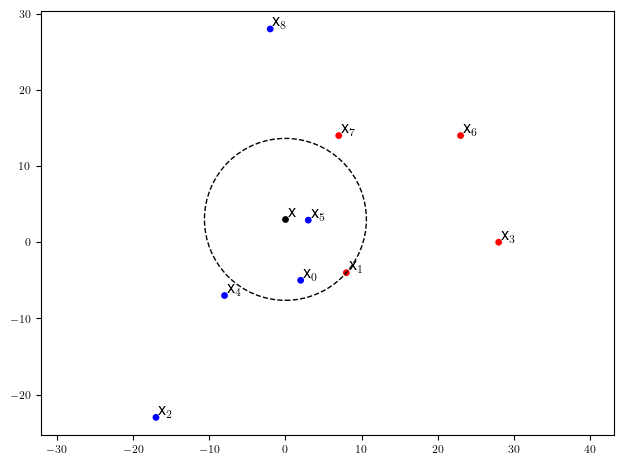

In [11]:
k=3

# <- completer ici
voisins = indices[::-1][:k]
print(voisins)

import matplotlib.pyplot as plt
import math
fig, ax = plt.subplots()
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.rc('font', **{'family': ['Helvetica'], 'size':12})
plt.rc('text', usetex=True)
colors = ['blue' if c == 1 else 'red' for c in y]
plt.scatter([u[0] for u in X], [u[1] for u in X],marker='.', s=[60]*len(X), c=colors)
plt.scatter((x[0]), (x[1]), marker='.', s=[60], c=('black'))
for i in range(len(X)):
    ax.annotate(r'x$_{}$'.format(str(i)), (X[i][0]+.3, X[i][1]+.3))
ax.annotate(r'x', (x[0]+.3, x[1]+.3))
cercle = plt.Circle(x, -math.log(sorted_values[-k]), color='black', linestyle='--',fill=False)
ax.add_patch(cercle)
plt.axis([-30, 30, -30, 30])
plt.axis('equal')
plt.tight_layout()
plt.show()

__Exercice__.$\quad$
Sélectionner les $k=3$ plus proches voisins de $x$ et les placer leurs classes dans la liste `classes_des_voisins`.

In [12]:
k=3
# <- completer ici
classes_des_voisins = [y[i] for i in voisins]
print(classes_des_voisins)

[1, 1, 0]


##### Etape 3 -- faire un vote majoritaire

Faire un vote majoritaire sur la liste `classes_des_voisins` et placer le résultat dans la variable `y`.

In [13]:
# <- completer ici
# y = ...
y = 1 if sum(classes_des_voisins)/len(classes_des_voisins) >= .5 else 0
print(y)

1
